In [3]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

df = pd.read_csv("../data/cleaned_online_retail.csv")

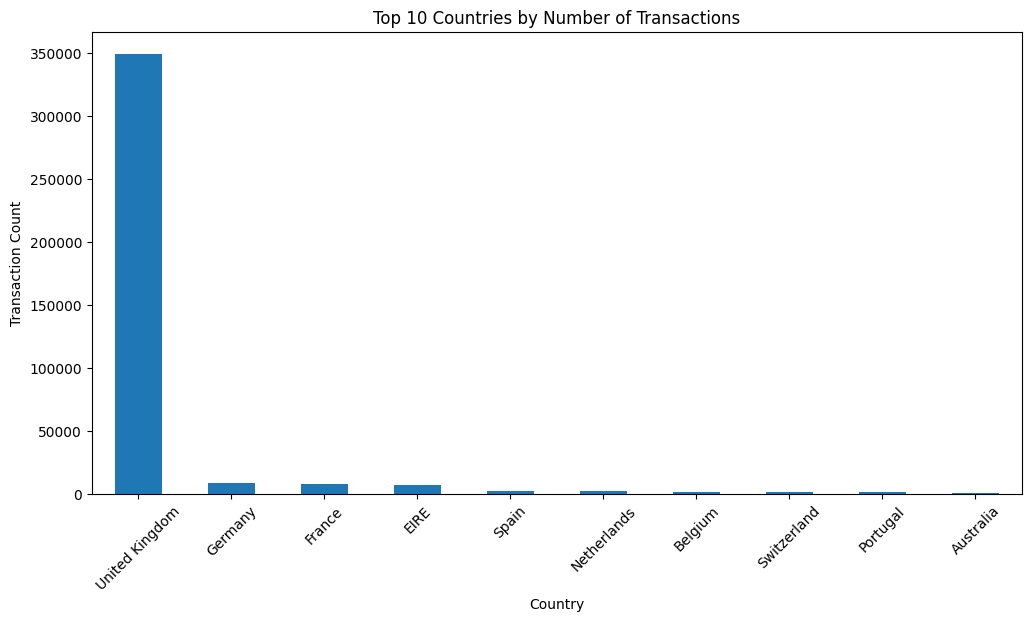

In [4]:
country_transactions = df.groupby('Country')['InvoiceNo'].count().sort_values(ascending=False)

plt.figure(figsize=(12,6))
country_transactions.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.show()

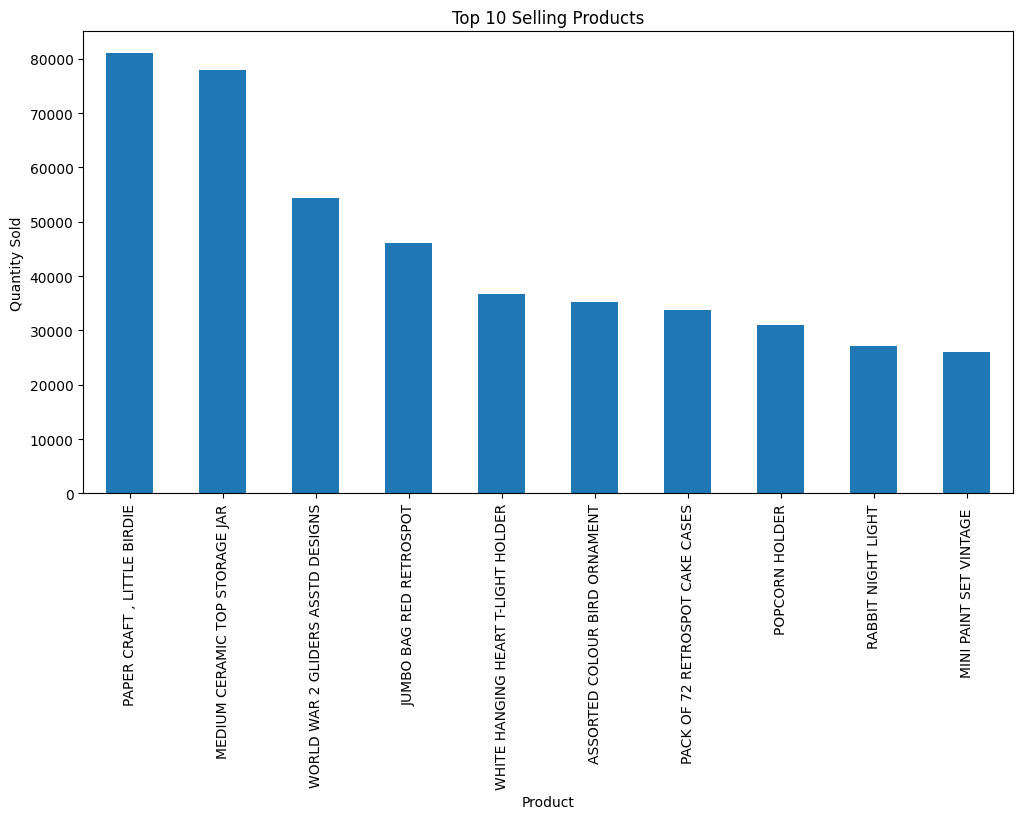

In [5]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar')
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=90)
plt.show()

In [9]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

In [10]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

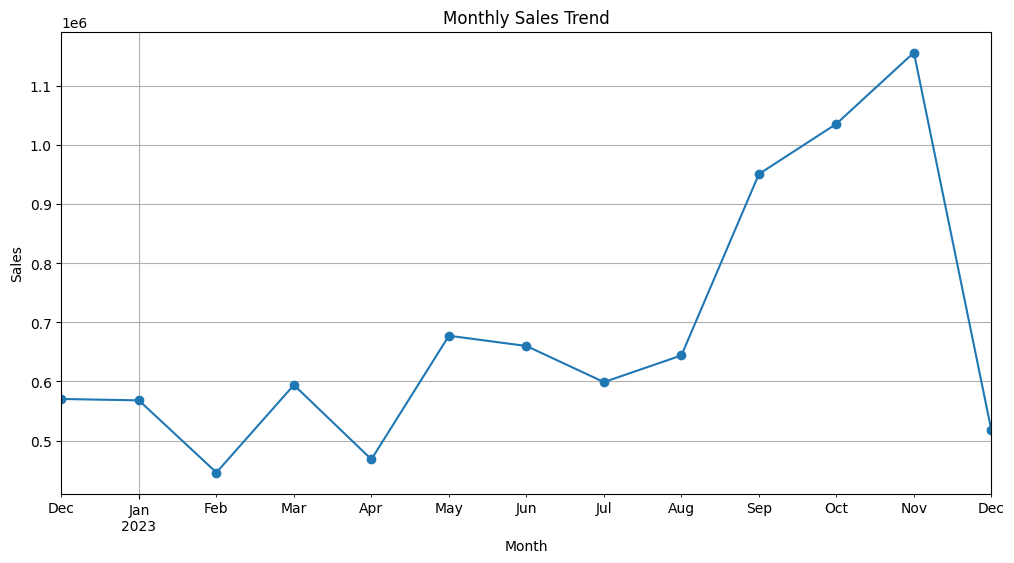

In [11]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

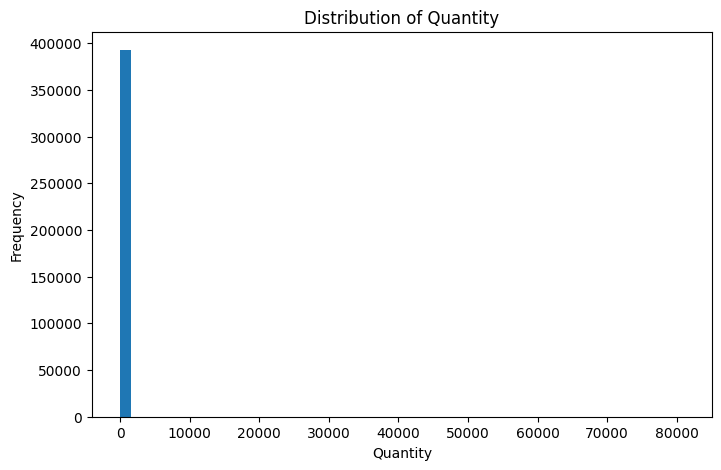

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df['Quantity'], bins=50)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

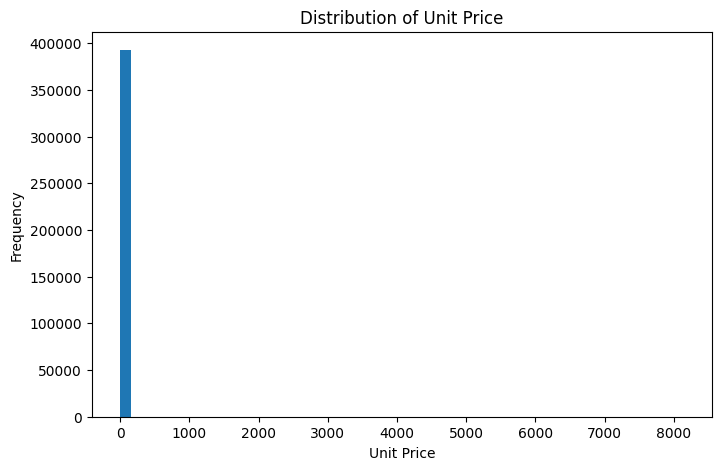

In [13]:
plt.figure(figsize=(8,5))
plt.hist(df['UnitPrice'], bins=50)
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

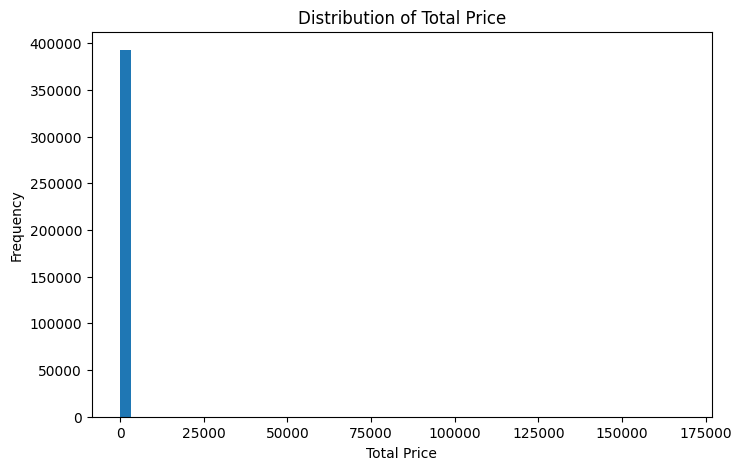

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['TotalPrice'], bins=50)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

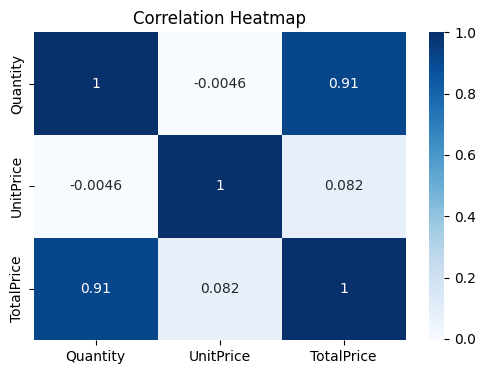

In [15]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(
    df[['Quantity','UnitPrice','TotalPrice']].corr(),
    annot=True,
    cmap='Blues'
)
plt.title("Correlation Heatmap")
plt.show()

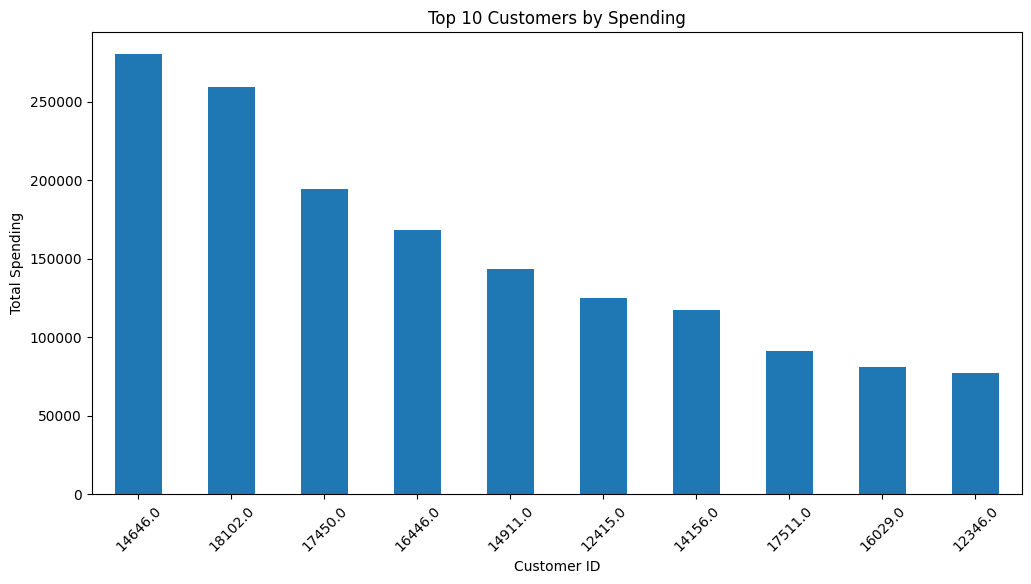

In [16]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.show()

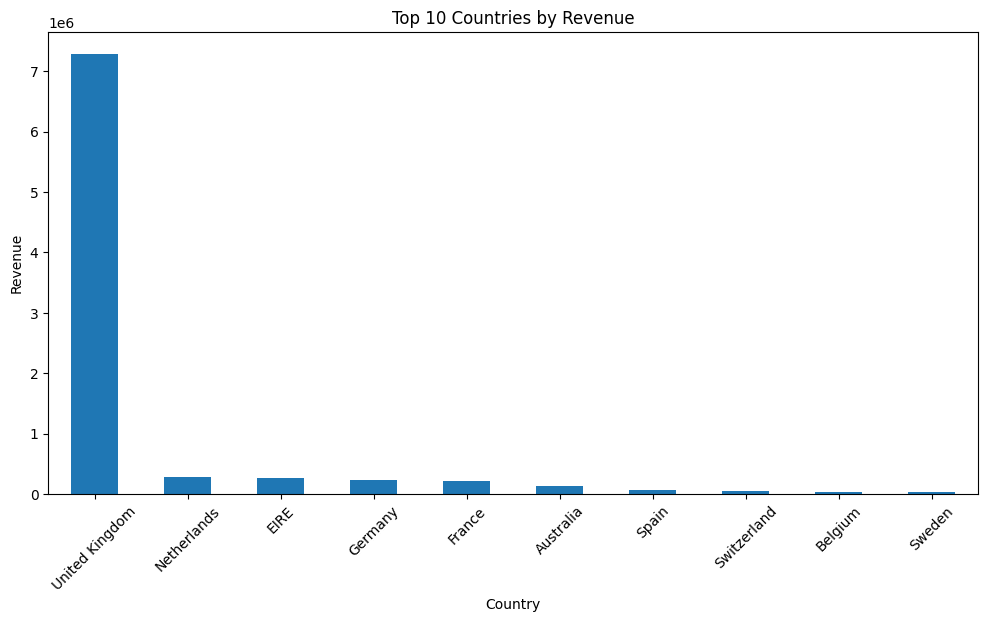

In [17]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
country_sales.plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [19]:
df.to_csv("../data/eda_online_retail.csv", index=False)